# Shared Cirrus + Orographic data-quality audit

## tl;dr

The shared mart is structurally valid and both systems now provide recommendation-time features, executable pricing fields, and immutable outcome timestamps. This audit also identified and verified fixes for three conformance defects: current Cirrus bundles were not guaranteed fresh in Orographic, 31.7% of Cirrus option sides were mislabeled, and Orographic path quotes were not linked to recommendations.

The two systems are **not yet collecting every field needed for mature joint learning**. The most important remaining limitations are sparse paired evidence, partial executable-outcome coverage, absent post-entry Greeks/liquidity on path marks, and source metadata that is collected upstream but not yet conformed into shared tables.


## Context & Methods

This notebook profiles the latest validated Orographic canonical bundle, the latest Git-published Cirrus research bundle, and a rebuilt observation-only shared mart. Checks cover freshness, grain, key integrity, completeness, point-in-time feature safety, path coverage, executable-label coverage, cross-system overlap, and data that is collected upstream but lost during conformance.

### Key assumptions

- A useful recommendation record needs an immutable run/recommendation identity, decision timestamp, contract identity, option side, entry quote, score or decision-stage score, and point-in-time features.
- Outcome labels are usable for training only when their availability timestamp is on or after the decision timestamp and the entry/exit prices are executable.
- “Path quote coverage” excludes entry-only marks; otherwise an emission quote would make every recommendation appear to have a price path.
- Same-date/symbol pairs are descriptive overlap, not an independent experiment or causal comparison.


In [1]:
from pathlib import Path
import json
import os

import matplotlib.pyplot as plt
import pandas as pd

OROGRAPHIC_CANONICAL_DIR = Path(os.environ.get("OROGRAPHIC_CANONICAL_DIR", "output/canonical_evidence"))
CIRRUS_BUNDLE_DIR = Path(os.environ.get("CIRRUS_BUNDLE_DIR", "../Cirrus/analysis/output/options_research_bundle"))
SHARED_MART_DIR = Path(os.environ.get("SHARED_MART_DIR", "output/shared_research_mart"))
CONSUMER_DIR = Path(os.environ.get("SHARED_MART_CONSUMER_DIR", "output/shared_mart_consumers"))
CAPTURE_AUDIT_PATH = Path(os.environ.get(
    "OROGRAPHIC_CAPTURE_AUDIT",
    str(OROGRAPHIC_CANONICAL_DIR.parent / "research_datasets" / "research_data_capture_audit.json"),
))

for required in (
    OROGRAPHIC_CANONICAL_DIR / "evidence_manifest.json",
    CIRRUS_BUNDLE_DIR / "manifest.json",
    SHARED_MART_DIR / "mart_manifest.json",
    CONSUMER_DIR / "consumer_manifest.json",
):
    if not required.exists():
        raise FileNotFoundError(required)

plt.style.use("seaborn-v0_8-whitegrid")
SOURCE_COLORS = {"orographic": "#4666C5", "cirrus": "#E07A3F"}


## Data

The source manifests are content-addressed and the shared mart validator enforces schemas, primary-key uniqueness, referential integrity, and point-in-time ordering. The tables below summarize the exact source snapshots used for this run.


In [2]:
orographic_manifest = json.loads((OROGRAPHIC_CANONICAL_DIR / "evidence_manifest.json").read_text())
cirrus_manifest = json.loads((CIRRUS_BUNDLE_DIR / "manifest.json").read_text())
mart_manifest = json.loads((SHARED_MART_DIR / "mart_manifest.json").read_text())
consumer_manifest = json.loads((CONSUMER_DIR / "consumer_manifest.json").read_text())
capture_audit = json.loads(CAPTURE_AUDIT_PATH.read_text()) if CAPTURE_AUDIT_PATH.exists() else {}

source_summary = pd.DataFrame([
    {
        "source": "Orographic",
        "bundle_id": orographic_manifest.get("bundle_id"),
        "generated_at_utc": orographic_manifest.get("generated_at_utc"),
        "recommendations": orographic_manifest.get("evidence", {}).get("cumulative_inventory", {}).get("primary", {}).get("recommendations", 0)
            + orographic_manifest.get("evidence", {}).get("cumulative_inventory", {}).get("moonshot", {}).get("recommendations", 0),
        "option_quote_rows": orographic_manifest.get("evidence", {}).get("cumulative_inventory", {}).get("option_quote_rows", 0),
    },
    {
        "source": "Cirrus",
        "bundle_id": cirrus_manifest.get("bundle_id"),
        "generated_at_utc": cirrus_manifest.get("generated_at"),
        "recommendations": cirrus_manifest.get("artifacts", {}).get("tracked_picks", {}).get("rows", 0),
        "option_quote_rows": cirrus_manifest.get("artifacts", {}).get("option_quote_snapshots", {}).get("rows", 0),
    },
])
source_summary


,source,bundle_id,generated_at_utc,recommendations,option_quote_rows
0,Orographic,1044bfb8c970c7b7dee1,2026-09-15T20:12:19+00:00,3635,3447060
1,Cirrus,c3cccc515d97958d55965053bb01ab26ae30f58d1b8637...,2026-09-15T19:35:12.958024+00:00,142,335


## Results

### 1. Collection and training coverage

Feature coverage is complete in the conformed mart. Outcome and post-entry path coverage remain the binding constraints. Historical sparsity is retained as missing rather than rewritten as zero.


In [3]:
quality = pd.read_parquet(CONSUMER_DIR / "mart_data_quality_v1.parquet")
funnel = pd.read_parquet(CONSUMER_DIR / "orographic_training_funnel_v1.parquet")
coverage = quality[[
    "source_system", "cohort", "recommendations", "feature_coverage_rate",
    "path_quote_coverage_rate", "executable_outcome_coverage_rate",
    "score_null_rate", "critical_null_rate",
]].copy()
coverage["score_coverage_rate"] = 1.0 - coverage["score_null_rate"]
coverage.sort_values(["source_system", "cohort"])


,source_system,cohort,recommendations,feature_coverage_rate,path_quote_coverage_rate,executable_outcome_coverage_rate,score_null_rate,critical_null_rate,score_coverage_rate
0,cirrus,prospective,142,1.0,1.000000,0.204225,0.0,0.0,1.0
2,orographic,moonshot,530,1.0,0.226415,0.743396,0.0,0.0,1.0
1,orographic,primary,3105,1.0,0.483414,0.555233,0.0,0.0,1.0


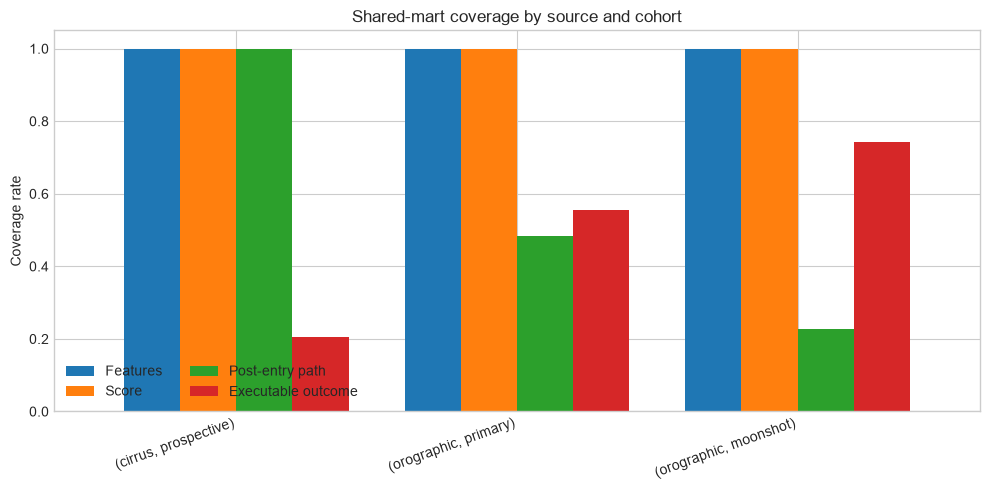

In [4]:
plot_data = coverage.set_index(["source_system", "cohort"])[[
    "feature_coverage_rate", "score_coverage_rate", "path_quote_coverage_rate",
    "executable_outcome_coverage_rate",
]].rename(columns={
    "feature_coverage_rate": "Features",
    "score_coverage_rate": "Score",
    "path_quote_coverage_rate": "Post-entry path",
    "executable_outcome_coverage_rate": "Executable outcome",
})
ax = plot_data.plot(kind="bar", figsize=(10, 5), width=0.8)
ax.set_title("Shared-mart coverage by source and cohort")
ax.set_ylabel("Coverage rate")
ax.set_xlabel("")
ax.set_ylim(0, 1.05)
ax.legend(loc="lower left", ncol=2)
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()


### 2. Cross-system overlap

The disagreement view selects one recommendation per source/date/symbol. A paired row therefore measures overlap in what the two systems happened to surface; it does not imply matched contracts, matched entry times, or independent treatment assignment.


In [5]:
disagreement = pd.read_parquet(CONSUMER_DIR / "cirrus_orographic_disagreement_v1.parquet")
paired = disagreement[
    disagreement["orographic_recommendation_key"].notna()
    & disagreement["cirrus_recommendation_key"].notna()
].copy()
paired_summary = pd.DataFrame([{
    "paired_date_symbol_rows": len(paired),
    "paired_market_dates": paired["market_date"].nunique(),
    "paired_executable_outcomes": int((
        paired["orographic_executable_return"].notna()
        & paired["cirrus_executable_return"].notna()
    ).sum()),
    "same_contract": int((paired["same_contract"] == True).sum()),
    "same_option_side": int((paired["same_side"] == True).sum()),
}])
paired_summary


,paired_date_symbol_rows,paired_market_dates,paired_executable_outcomes,same_contract,same_option_side
0,10,8,2,0,5


### 3. Upstream data not yet represented in the shared contract

Cirrus already records multi-leg structure and experiment governance, but the current shared mart has no conformed tables for those records. This is a conformance gap rather than a source-collection failure.


In [6]:
position_legs = pd.read_parquet(CIRRUS_BUNDLE_DIR / "position_legs.parquet")
experiment_tags = pd.read_parquet(CIRRUS_BUNDLE_DIR / "pick_experiment_tags.parquet")
scan_decisions = pd.read_parquet(CIRRUS_BUNDLE_DIR / "experiment_scan_decisions.parquet")

upstream_only = pd.DataFrame([
    {
        "record family": "Position legs",
        "raw rows": len(position_legs),
        "affected recommendations": int(position_legs.groupby("tracked_pick_id").size().gt(1).sum()),
        "shared-table status": "Not conformed",
    },
    {
        "record family": "Experiment tags",
        "raw rows": len(experiment_tags),
        "affected recommendations": experiment_tags["tracked_pick_id"].nunique(),
        "shared-table status": "Not conformed",
    },
    {
        "record family": "Experiment scan decisions",
        "raw rows": len(scan_decisions),
        "affected recommendations": 0,
        "shared-table status": "Not conformed",
    },
])
upstream_only


,record family,raw rows,affected recommendations,shared-table status
0,Position legs,158,16,Not conformed
1,Experiment tags,14,14,Not conformed
2,Experiment scan decisions,8,0,Not conformed


### 4. Remaining collection gaps and priorities

Severity reflects the intended use of an observation-only research mart. “High” means the gap can materially distort a direct cross-system comparison or prevent a valid shared model; it does not mean production routing is currently unsafe.


In [7]:
oro_primary = quality[(quality.source_system == "orographic") & (quality.cohort == "primary")].iloc[0]
cirrus = quality[quality.source_system == "cirrus"].iloc[0]
event_coverage = capture_audit.get("summary", {}).get("complete_outcome_event_coverage_pct")

gaps = pd.DataFrame([
    {
        "priority": "High",
        "gap": "Paired executable evidence",
        "evidence": f"{paired_summary.loc[0, 'paired_executable_outcomes']} paired executable outcomes across {paired_summary.loc[0, 'paired_market_dates']} market dates",
        "smallest useful remediation": "Run both collectors on aligned weekday dates/universes and retain one comparable candidate per date/symbol.",
    },
    {
        "priority": "High",
        "gap": "Partial executable labels",
        "evidence": f"Orographic primary {oro_primary.executable_outcome_coverage_rate:.1%}; Cirrus {cirrus.executable_outcome_coverage_rate:.1%}",
        "smallest useful remediation": "Keep scheduled post-entry capture running and alert on new-cohort coverage regressions.",
    },
    {
        "priority": "Medium",
        "gap": "Post-entry Greeks/liquidity",
        "evidence": f"Null IV rates: Orographic {oro_primary.path_null_iv_rate:.1%}; Cirrus {cirrus.path_null_iv_rate:.1%}",
        "smallest useful remediation": "Persist IV, Greeks, open interest, volume, and quote age with each new path mark when the provider supplies them.",
    },
    {
        "priority": "Medium",
        "gap": "Structure and experiment metadata",
        "evidence": f"{int((position_legs.groupby('tracked_pick_id').size() > 1).sum())} multi-leg Cirrus picks and {len(experiment_tags)} experiment tags are upstream-only",
        "smallest useful remediation": "Add provider-neutral recommendation_legs and experiment_decisions tables in mart schema v2.",
    },
    {
        "priority": "Medium",
        "gap": "Decision-time version provenance",
        "evidence": "Cirrus model_version is currently a lane label rather than a decision-time artifact or code revision.",
        "smallest useful remediation": "Capture code revision and model artifact hashes on each Cirrus scan run and map them into model_runs/recommendations.",
    },
    {
        "priority": "Medium",
        "gap": "Outcome-event joins",
        "evidence": f"Complete outcome event coverage: {event_coverage if event_coverage is not None else 'unavailable'}%",
        "smallest useful remediation": "Repair event lookback joins and monitor event-feed cooldown/freshness independently from recommendation capture.",
    },
])
gaps


,priority,gap,evidence,smallest useful remediation
0,High,Paired executable evidence,2 paired executable outcomes across 8 market d...,Run both collectors on aligned weekday dates/u...
1,High,Partial executable labels,Orographic primary 55.5%; Cirrus 20.4%,Keep scheduled post-entry capture running and ...
2,Medium,Post-entry Greeks/liquidity,Null IV rates: Orographic 100.0%; Cirrus 71.0%,"Persist IV, Greeks, open interest, volume, and..."
3,Medium,Structure and experiment metadata,16 multi-leg Cirrus picks and 14 experiment ta...,Add provider-neutral recommendation_legs and e...
4,Medium,Decision-time version provenance,Cirrus model_version is currently a lane label...,Capture code revision and model artifact hashe...
5,Medium,Outcome-event joins,Complete outcome event coverage: 0.0%,Repair event lookback joins and monitor event-...


## Takeaways

1. The shared mart is usable for observation and training within each source, with content-addressed inputs and point-in-time feature guards.
2. The current PR closes the freshness, option-side, score-selection, and Orographic path-linking defects found by this audit.
3. Cross-system claims remain premature: paired executable evidence is still far below the existing 30-outcome/30-date shadow gates.
4. The next schema should preserve recommendation legs, experiment decisions, and decision-time code/model provenance. New path marks should also carry liquidity and volatility state when available.
5. Production authority remains frozen; none of these audit results authorizes routing, sizing, or model promotion.
